<a href="https://colab.research.google.com/github/Dipenderiitr295/ML-demo/blob/main/Iris_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
iris = load_iris(as_frame=True)
df = iris.frame
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
iris = load_iris(as_frame=True)
df = iris.frame
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [ ]:
iris = load_iris(as_frame=True)
df = iris.frame
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [ ]:
iris = load_iris(as_frame=True)
df = iris.frame
df.tail(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
140,6.7,3.1,5.6,2.4,2
141,6.9,3.1,5.1,2.3,2
142,5.8,2.7,5.1,1.9,2
143,6.8,3.2,5.9,2.3,2
144,6.7,3.3,5.7,2.5,2
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [ ]:
print("Dataset shape:", df.shape)
print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)
print("Samples per class:")
print(df["target"].value_counts().sort_index())

Dataset shape: (150, 5)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Samples per class:
target
0    50
1    50
2    50
Name: count, dtype: int64


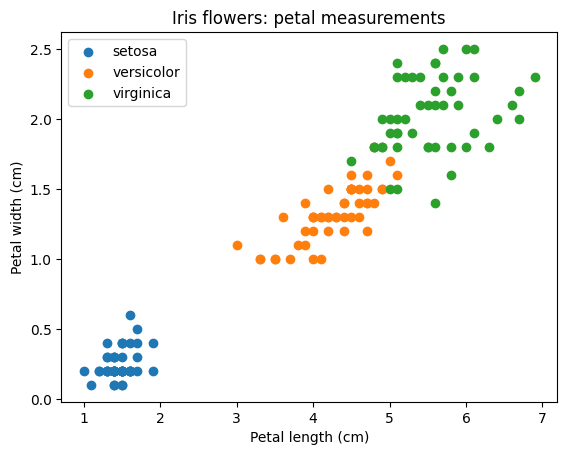

In [ ]:
for class_id, class_name in enumerate(iris.target_names):
 subset = df[df["target"] == class_id]
 plt.scatter(
 subset["petal length (cm)"],
 subset["petal width (cm)"],
 label=class_name
 )
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Iris flowers: petal measurements")
plt.legend()
plt.show()

In [ ]:
X = df[iris.feature_names]
y = df["target"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
 X,
 y,
 test_size=0.20,
 random_state=42,
 stratify=y
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Test class counts:")
print(y_test.value_counts().sort_index())

Training samples: 120
Testing samples: 30
Test class counts:
target
0    10
1    10
2    10
Name: count, dtype: int64


In [ ]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [ ]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy percentage:", f"{accuracy * 100:.2f}%")

Accuracy: 0.9666666666666667
Accuracy percentage: 96.67%


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:")
print(cm)
print("Classification report:")
print(classification_report(
 y_test,
 y_pred,
 target_names=iris.target_names
))


Confusion matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
new_flower = pd.DataFrame(
 [[5.0, 3.4, 1.5, 0.2]],
 columns=iris.feature_names
)
predicted_class = model.predict(new_flower)[0]
probabilities = model.predict_proba(new_flower)[0]
print("Predicted class number:", predicted_class)
print("Predicted species:", iris.target_names[predicted_class])
print("Class probabilities:", probabilities)

Predicted class number: 0
Predicted species: setosa
Class probabilities: [9.73098483e-01 2.69014200e-02 9.67436641e-08]


In [18]:
df.shape

(150, 5)